# Member 2 — LSTM Model
## CCS3356 Natural Language Processing | Fake News Detection
### Student ID: CIT-24-01-0486
### DL Model: LSTM with GloVe 100d Embeddings

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU available: True


In [9]:
df = pd.read_csv('preprocessed.csv')
df['cleaned_text'] = df['cleaned_text'].fillna('')

X = df['cleaned_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.fillna('')
X_test = X_test.fillna('')

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 35918 | Test: 8980


In [10]:
MAX_WORDS = 50000
MAX_LEN = 500

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"X_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad shape:  {X_test_pad.shape}")

Vocabulary size: 179207
X_train_pad shape: (35918, 500)
X_test_pad shape:  (8980, 500)


In [11]:
# Download GloVe embeddings
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip -d glove
print("GloVe downloaded!")

# Load GloVe 100d
embeddings_index = {}
with open('glove/glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Loaded {len(embeddings_index)} word vectors from GloVe")

GloVe downloaded!
Loaded 400000 word vectors from GloVe


In [12]:
EMBEDDING_DIM = 100
word_index = tokenizer.word_index

embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))
found = 0

for word, i in word_index.items():
    if i < MAX_WORDS:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
            found += 1

print(f"Words found in GloVe: {found} / {min(len(word_index), MAX_WORDS)}")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Words found in GloVe: 37590 / 50000
Embedding matrix shape: (50000, 100)


In [13]:
from tensorflow.keras.layers import BatchNormalization

model = Sequential([
    Embedding(MAX_WORDS, EMBEDDING_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=True),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,000,000 (19.07 MB)

 Trainable params: 5,000,000 (19.07 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=3,
                           restore_best_weights=True, mode='max')

history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("Training complete!")

Epoch 1/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 51s 42ms/step - accuracy: 0.5181 - loss: 0.7010 - val_accuracy: 0.5298 - val_loss: 0.7111
Epoch 2/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 42s 42ms/step - accuracy: 0.5283 - loss: 0.6658 - val_accuracy: 0.5434 - val_loss: 0.6442
Epoch 3/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 43s 42ms/step - accuracy: 0.5439 - loss: 0.6499 - val_accuracy: 0.5810 - val_loss: 0.6208
Epoch 4/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 43s 42ms/step - accuracy: 0.5645 - loss: 0.6317 - val_accuracy: 0.6609 - val_loss: 0.5662
Epoch 5/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.6654 - loss: 0.5560 - val_accuracy: 0.7060 - val_loss: 0.5123
Epoch 6/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 43s 42ms/step - accuracy: 0.5580 - loss: 0.6617 - val_accuracy: 0.4758 - val_loss: 0.6965
Epoch 7/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 42s 42ms/step - accuracy: 0.7647 - loss: 0.3834 - val_accuracy: 0.9983 - val_loss: 0.0095
Epoch 8/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 42s 42ms/step - accuracy: 0.9950 -

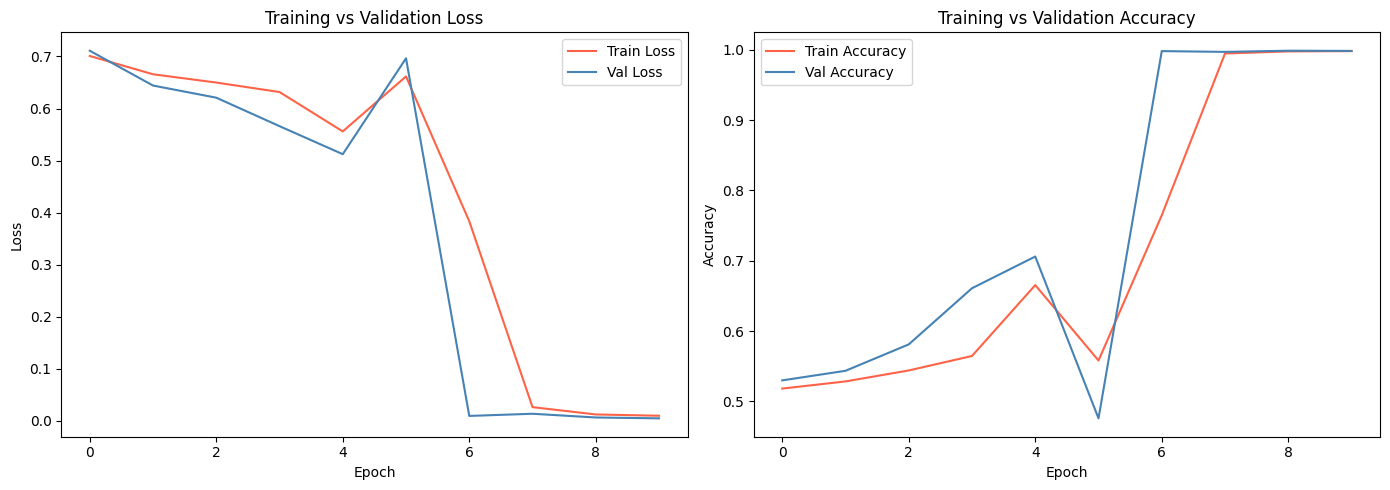

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='tomato')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='steelblue')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='tomato')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='steelblue')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('m2_lstm_training_curves.png')
plt.show()

In [16]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("LSTM Evaluation Results:")
print("-" * 40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step
LSTM Evaluation Results:
----------------------------------------
Accuracy:  0.9969
Precision: 0.9951
Recall:    0.9989
F1-Score:  0.9970
ROC-AUC:   0.9993

Classification Report:
              precision    recall  f1-score   support

        Real       1.00      0.99      1.00      4284
        Fake       1.00      1.00      1.00      4696

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



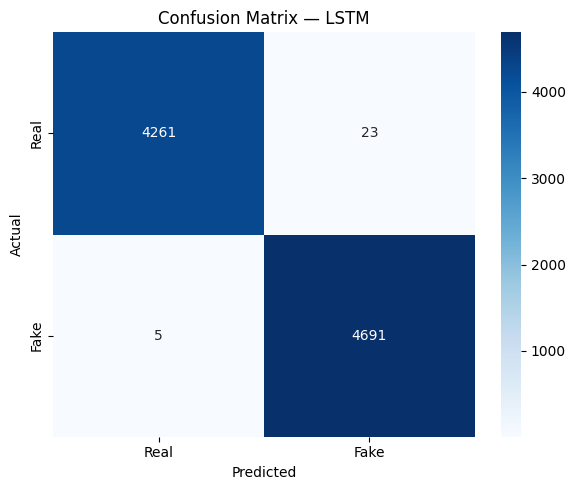

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix — LSTM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('m2_lstm_confusion_matrix.png')
plt.show()

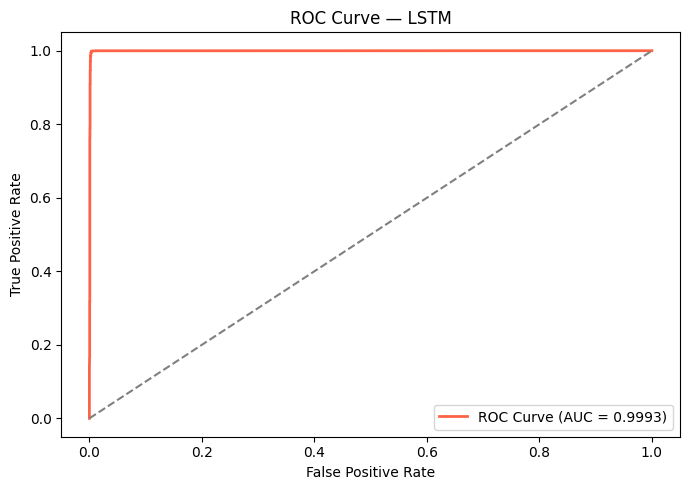

In [18]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='tomato', lw=2,
         label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_prob):.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — LSTM')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('m2_lstm_roc_curve.png')
plt.show()

In [19]:
model.save('m2_lstm_model.h5')
print("LSTM model saved as m2_lstm_model.h5")

LSTM model saved as m2_lstm_model.h5


In [20]:
from google.colab import files

files.download('m2_lstm_model.h5')
files.download('m2_lstm_training_curves.png')
files.download('m2_lstm_confusion_matrix.png')
files.download('m2_lstm_roc_curve.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>